# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load Dataset

In [7]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)

print(df.shape)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Separate Features and Target

In [8]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

# Feature Scaling

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


# Detect Overfitting (Train vs Test)

In [16]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {test_rmse:.4f}")

Train RMSE : 0.0000
Test RMSE  : 0.7030


# Cross Validation

In [19]:
cv_scores = cross_val_score(
    tree, X_scaled, y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse = -cv_scores.mean()
print(f"CV RMSE : {cv_rmse:.4f}")

CV RMSE : 0.8957


# Hyperparameter Tuning with GridSearchCV

In [23]:
param_grid = {
    "max_depth":        [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 10}


# Evaluate Tuned Model

In [28]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

RMSE : 0.6454
R2   : 0.6821


# Baseline Models for Comparison

In [37]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
best_tree = grid.best_estimator_
tree_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
r2 = r2_score(y_test, tree_pred)

print(f"Linear Regression   — RMSE: {lr_rmse:.4f}  R2: {lr_r2:.4f}")
print(f"Ridge Regression    — RMSE: {ridge_rmse:.4f}  R2: {ridge_r2:.4f}")
print(f"Tuned Decision Tree — RMSE: {rmse:.4f}  R2: {r2:.4f}")

Linear Regression   — RMSE: 0.7456  R2: 0.5758
Ridge Regression    — RMSE: 0.7456  R2: 0.5758
Tuned Decision Tree — RMSE: 0.6454  R2: 0.6821


# Model Comparison Table

In [40]:
results = {
    "Model":    ["Linear Regression", "Ridge Regression", "Tuned Decision Tree"],
    "RMSE":     [round(lr_rmse, 4), round(ridge_rmse, 4), round(rmse, 4)],
    "R2 Score": [round(lr_r2, 4),   round(ridge_r2, 4),   round(r2, 4)]
}

pd.DataFrame(results)


,Model,RMSE,R2 Score
0,Linear Regression,0.7456,0.5758
1,Ridge Regression,0.7456,0.5758
2,Tuned Decision Tree,0.6454,0.6821


# Overfitting Plot (Train vs Test RMSE)

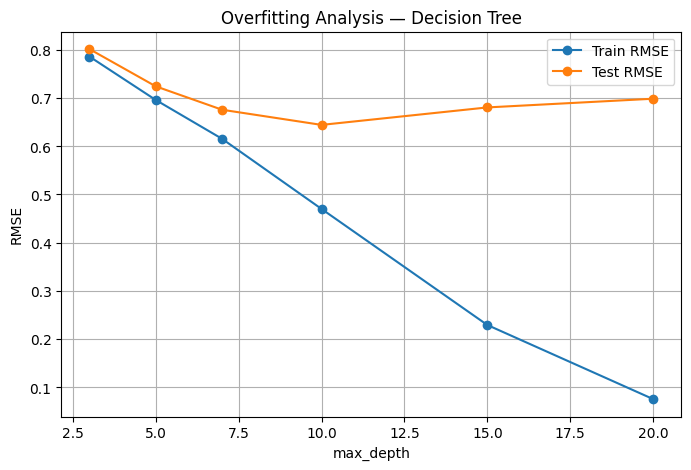

In [45]:
depths = [3, 5, 7, 10, 15, 20]
train_scores = []
test_scores = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d, random_state=42)
    m.fit(X_train, y_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, m.predict(X_train)))
    test_rmse = np.sqrt(mean_squared_error(y_test, m.predict(X_test)))

    train_scores.append(train_rmse)
    test_scores.append(test_rmse)

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, marker='o', label='Train RMSE')
plt.plot(depths, test_scores, marker='o', label='Test RMSE')

plt.xlabel("max_depth")
plt.ylabel("RMSE")
plt.title("Overfitting Analysis — Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

# Actual vs Predicted (Tuned Model)

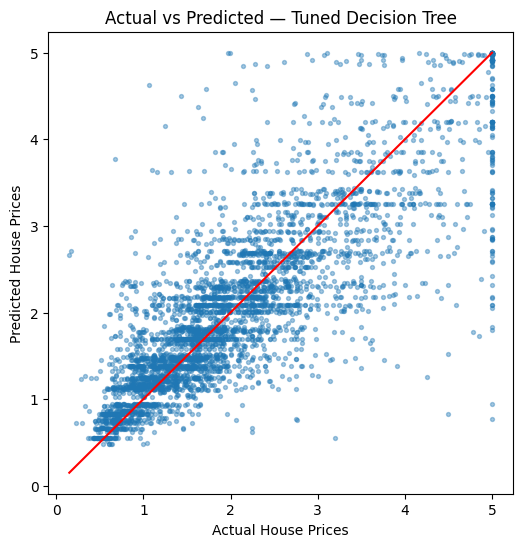

In [47]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4, s=8)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted — Tuned Decision Tree")
plt.show()

# Save Best Model

In [48]:
import joblib

joblib.dump(best_tree, "best_model_task3.pkl")
joblib.dump(scaler,    "scaler.pkl")
print("model saved")

model saved
